In [7]:
import json
import subprocess
import sys
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import random

sys.path.append('../../../framework/PythonTools')

from Spacepoint import Spacepoint
from Solution import Solution
from ParticleInitial import ParticleInitial
from MathFunctions import *
from TestsCommon import *

`erase_test_list()` is defined in `TestsCommon.py` and is here not to run all tests when you are working on a single test.

If you want to run all tests, uncomment `erase_test_list()`, run all, run `runTests.py` `/helix/repo` in container, and then run all again.

In [8]:
# def erase_test_list():
#     pass

In [9]:
base_dir = "/helix/repo/test_results"
base_dir_relative = "../../../test_results"
data_dir = "/helix/repo/data/odd_output_ttbar_PU200_100"
data_dir_relative = "../../../data/odd_output_ttbar_PU200_100"

generic_test_params = SolverTestParams()
generic_test_params.testType = ""
generic_test_params.eventId = 0
generic_test_params.multipleEventIds = []
generic_test_params.numRuns = 0
generic_test_params.inputSpacepointsFile = data_dir + "/spacepoints.root"
generic_test_params.inputParticlesInitialFile = data_dir + "/particles_initial.root"
generic_test_params.inputSpacepointsGenerationParamsFile = ""
generic_test_params.outputResultsFile = ""
generic_test_params.maxAbsXy = 1100.0
generic_test_params.maxAbsZ = 3100.0
generic_test_params.minZAngle = 0.0
generic_test_params.maxZAngle = 2 * math.pi
generic_test_params.minXAngle = math.pi * 5 / 256
generic_test_params.maxXAngle = math.pi * 251 / 256
generic_test_params.poleRegionAngle = math.pi * 5 / 256
generic_test_params.interactionRegionMin = -200.0
generic_test_params.interactionRegionMax = 200.0
generic_test_params.zAngleMargin = math.pi / 32
generic_test_params.xAngleMargin = math.pi / 128
generic_test_params.numZRanges = 32
generic_test_params.numXRanges = 48
generic_test_params.filterOutCenterR = 140.0
generic_test_params.filterOutCenterZ = 550.0
generic_test_params.hitsThresholds = [7 for _ in range(generic_test_params.numXRanges)]
generic_test_params.linesCrossingsThresholds = [3 for _ in range(generic_test_params.numXRanges)]

In [10]:
class Performance:
    def __init__(self, event_id, run_id, total, splitter, solver):
        self.event_id = event_id
        self.run_id = run_id
        self.total = total
        self.splitter = splitter
        self.solver = solver

    def __str__(self):
        return f"Performance(event_id={self.event_id}, run_id={self.run_id}, total={self.total}, splitter={self.splitter}, solver={self.solver})"

    @staticmethod
    def read_from_csv(path):
        with open(path, 'r') as file:
            lines = file.readlines()

        performances = []
        for line in lines[1:]:
            line = [i.strip() for i in line.split(",")]
            event_id = int(line[0])
            run_id = int(line[1])
            total = float(line[2])
            splitter = float(line[3])
            solver = float(line[4])
            performances.append(Performance(event_id, run_id, total, splitter, solver))

        return performances

# S execution time heatmap by num ranges

In [11]:
erase_test_list()

In [12]:
test_params = copy.copy(generic_test_params)
test_params.multipleEventIds = [i for i in range(20)]
test_params.numRuns = 1
test_params.testType = "SpacepointsSingleEventPerformance"
test_params.outputResultsFile = base_dir + "/performance_tests/s_execution_by_num_ranges/results.csv"

num_x_rangess = [i for i in range(8, 65, 4)]
num_z_rangess = [i for i in range(8, 65, 4)]
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        test_params.numXRanges = num_x_ranges
        test_params.numZRanges = num_z_ranges
        test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
        test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
        test_params.outputResultsFile = base_dir + f"/performance_tests/s_execution_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv"
        write_config(test_params, base_dir_relative + "/performance_tests/s_execution_by_num_ranges", base_dir_relative + f"/performance_tests/s_execution_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")
        add_test_to_list(base_dir + f"/performance_tests/s_execution_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")

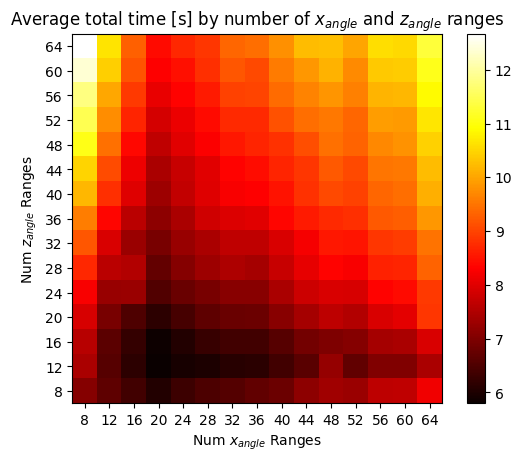

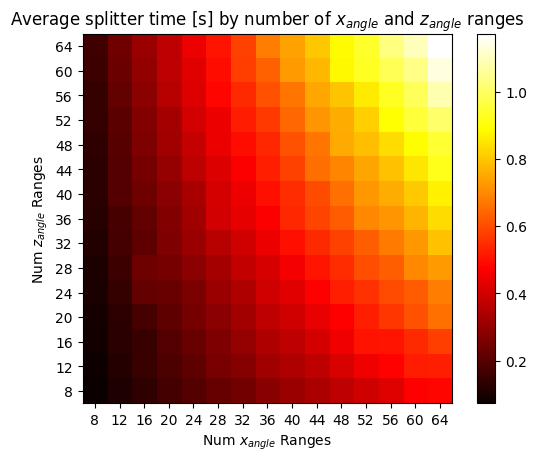

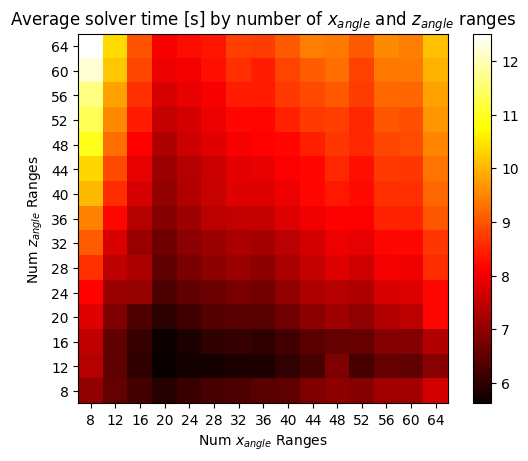

In [13]:
performances_by_num_ranges = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        if (num_x_ranges, num_z_ranges) not in performances_by_num_ranges:
            performances_by_num_ranges[(num_x_ranges, num_z_ranges)] = []
        performances_by_num_ranges[(num_x_ranges, num_z_ranges)].extend(Performance.read_from_csv(base_dir_relative + f"/performance_tests/s_execution_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv"))

average_total_by_num_ranges = {}
average_splitter_by_num_ranges = {}
average_solver_by_num_ranges = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        sum_total = sum([performance.total for performance in performances_by_num_ranges[(num_x_ranges, num_z_ranges)]])
        sum_splitter = sum([performance.splitter for performance in performances_by_num_ranges[(num_x_ranges, num_z_ranges)]])
        sum_solver = sum([performance.solver for performance in performances_by_num_ranges[(num_x_ranges, num_z_ranges)]])
        average_total_by_num_ranges[(num_x_ranges, num_z_ranges)] = sum_total / len(performances_by_num_ranges[(num_x_ranges, num_z_ranges)]) / 1e9
        average_splitter_by_num_ranges[(num_x_ranges, num_z_ranges)] = sum_splitter / len(performances_by_num_ranges[(num_x_ranges, num_z_ranges)]) / 1e9
        average_solver_by_num_ranges[(num_x_ranges, num_z_ranges)] = sum_solver / len(performances_by_num_ranges[(num_x_ranges, num_z_ranges)]) / 1e9

draw_heat_map(average_total_by_num_ranges, num_x_rangess, num_z_rangess, "Average total time [s] by number of $x_{angle}$ and $z_{angle}$ ranges", "Num $x_{angle}$ Ranges", "Num $z_{angle}$ Ranges")
draw_heat_map(average_splitter_by_num_ranges, num_x_rangess, num_z_rangess, "Average splitter time [s] by number of $x_{angle}$ and $z_{angle}$ ranges", "Num $x_{angle}$ Ranges", "Num $z_{angle}$ Ranges")
draw_heat_map(average_solver_by_num_ranges, num_x_rangess, num_z_rangess, "Average solver time [s] by number of $x_{angle}$ and $z_{angle}$ ranges", "Num $x_{angle}$ Ranges", "Num $z_{angle}$ Ranges")

# S execution time for selected thresholds

In [14]:
erase_test_list()

In [15]:
test_params = copy.copy(generic_test_params)
test_params.multipleEventIds = [i for i in range(20)]
test_params.numRuns = 5
test_params.testType = "SpacepointsSingleEventPerformance"
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 9
test_params.hitsThresholds[1] = 9
test_params.hitsThresholds[2] = 8
test_params.hitsThresholds[3] = 8
test_params.hitsThresholds[4] = 7

test_params.hitsThresholds[5:11] = [6 for _ in range(6)]
test_params.hitsThresholds[-12:-6] = [6 for _ in range(6)]

test_params.hitsThresholds[-5] = 7
test_params.hitsThresholds[-4] = 8
test_params.hitsThresholds[-3] = 8
test_params.hitsThresholds[-2] = 9
test_params.hitsThresholds[-1] = 9

test_params.outputResultsFile = base_dir + f"/performance_tests/s_custom_thresholds_execution_times_hot/results.csv"
write_config(test_params, base_dir_relative + "/performance_tests/s_custom_thresholds_execution_times_hot", base_dir_relative + f"/performance_tests/s_custom_thresholds_execution_times_hot/config.json")
add_test_to_list(base_dir + f"/performance_tests/s_custom_thresholds_execution_times_hot/config.json")

In [16]:
def get_averages(performances):
    average_total = sum([performance.total for performance in performances]) / len(performances) / 1e9
    average_splitter = sum([performance.splitter for performance in performances]) / len(performances) / 1e9
    average_solver = sum([performance.solver for performance in performances]) / len(performances) / 1e9
    return average_total, average_splitter, average_solver

performances = Performance.read_from_csv(base_dir_relative + "/performance_tests/s_custom_thresholds_execution_times_hot/results.csv")
average_total, average_splitter, average_solver = get_averages(performances)

print("Execution times for custom per-range hits thresholds, hot hardware")
print(f"Average total: {average_total:.2f} s")
print(f"Average splitter: {average_splitter:.2f} s")
print(f"Average solver: {average_solver:.2f} s")
print()

Execution times for custom per-range hits thresholds, hot hardware
Average total: 8.55 s
Average splitter: 0.59 s
Average solver: 7.97 s



In [17]:
erase_test_list()

In [18]:
test_params.outputResultsFile = base_dir + f"/performance_tests/s_custom_thresholds_execution_times_cold/results.csv"
write_config(test_params, base_dir_relative + "/performance_tests/s_custom_thresholds_execution_times_cold", base_dir_relative + f"/performance_tests/s_custom_thresholds_execution_times_cold/config.json")
add_test_to_list(base_dir + f"/performance_tests/s_custom_thresholds_execution_times_cold/config.json")

In [19]:
def get_averages(performances):
    average_total = sum([performance.total for performance in performances]) / len(performances) / 1e9
    average_splitter = sum([performance.splitter for performance in performances]) / len(performances) / 1e9
    average_solver = sum([performance.solver for performance in performances]) / len(performances) / 1e9
    return average_total, average_splitter, average_solver

performances = Performance.read_from_csv(base_dir_relative + "/performance_tests/s_custom_thresholds_execution_times_cold/results.csv")
average_total, average_splitter, average_solver = get_averages(performances)

print("Execution times for custom per-range hits thresholds, cold hardware")
print(f"Average total: {average_total:.2f} s")
print(f"Average splitter: {average_splitter:.2f} s")
print(f"Average solver: {average_solver:.2f} s")
print()

Execution times for custom per-range hits thresholds, cold hardware
Average total: 8.24 s
Average splitter: 0.57 s
Average solver: 7.67 s

